# Bounding-box tightening — demo walkthrough

MIDOG++ ground truth is a single pathologist **point click** per mitotic figure, not a
real bounding box — `databases/MIDOG++.json`'s `bbox` field is a synthetic
`point ± 25` square (see `Research Logs/2026-08-25-bbox-tuning-domain-mismatch.md`).
That 50x50 box is a poor template for matching: it's rarely centred on the actual
chromatin mass and is almost always larger than the object itself.

**Bbox tightening** replaces that synthetic box with the real extent of the nucleus
under the click, by Otsu-thresholding a small crop around the point and taking the
connected component the click lands in. This notebook runs the production
implementation — `midog_utils.seed_selection.tighten_box_otsu` — and unpacks every
step it performs internally, so each intermediate array is visible on its own.

Two things this notebook shows:

1. **One annotation, every preprocessing step** — from the raw RGB crop to the final
   tightened box, replicating `tighten_box_otsu`'s internals one operation at a time
   and cross-checking the result against the real function.
2. **One example image per domain** — all seven MIDOG++ tumor types, showing both
   successful tightenings and the annotations the method correctly refuses to tighten.

Background and design rationale: `Research Logs/design_choices.md` (sections 1-2, 7,
7a, 7b) and `Research Logs/2026-08-25-bbox-tuning-domain-mismatch.md`. API reference:
`BBOX_TUNING.md` in the repo root.

In [1]:
import sys
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from skimage.measure import label, regionprops

sys.path.insert(0, str(Path.cwd()))
from midog_utils import dataset, channels, template_match as tm, seed_selection as ss

print("numpy", np.__version__, "| opencv", cv2.__version__)

images, anns = dataset.load_annotations()
IMAGES_DIR = Path("images")
Path("debug_pics").mkdir(exist_ok=True)  # created up front -- every debug image this notebook saves lands here

numpy 1.26.4 | opencv 4.8.1


## Picking one annotation to walk through

`002.tiff` (human breast cancer) is the same sample image used throughout
`Research Logs/`. Annotation `ann_id=10` is a clean, non-border-touching mitotic
figure — a representative case for the full step-by-step below. (A case the method
*rejects* is shown separately, further down.)

002.tiff ann 10: click at (cx=6267, cy=3218), ROI shape (5412, 7215, 3)


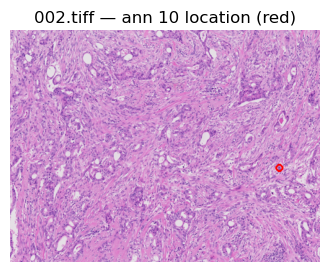

In [2]:
FNAME = "002.tiff"
ANN_ID = 10

rgb = dataset.load_roi(IMAGES_DIR / FNAME)
mit = dataset.image_annotations(anns, FNAME, category_id=1)
row = mit[mit["ann_id"] == ANN_ID].iloc[0]
cx, cy = float(row["cx"]), float(row["cy"])
print(f"{FNAME} ann {ANN_ID}: click at (cx={cx:.0f}, cy={cy:.0f}), ROI shape {rgb.shape}")

# Where this annotation sits in the full ROI (thumbnail, for orientation only)
thumb = Image.fromarray(rgb).copy()
thumb.thumbnail((500, 500))
scale = thumb.width / rgb.shape[1]
draw = ImageDraw.Draw(thumb)
r = 6
draw.ellipse([cx * scale - r, cy * scale - r, cx * scale + r, cy * scale + r], outline="red", width=3)
plt.figure(figsize=(4, 4))
plt.imshow(thumb)
plt.title(f"{FNAME} — ann {ANN_ID} location (red)")
plt.axis("off")
plt.show()

## Step 1 — read a padded patch around the click

`template_match.read_padded_patch` crops a square window centred on `(cx, cy)`.
Bbox tightening uses the **annotation-box-sized** window (`template_match.BASE_SIZE`,
51px — the 50x50 box made odd so the click lands exactly on the centre pixel), not the
wider rotation-safe `PATCH_SIZE` window used later for template matching itself:
a wider window lets Otsu bridge into neighbouring nuclei in dense tissue
(`foreground_filter`'s docstring, calibrated on `246.tiff`).

rgb_patch shape: (51, 51, 3) uint8


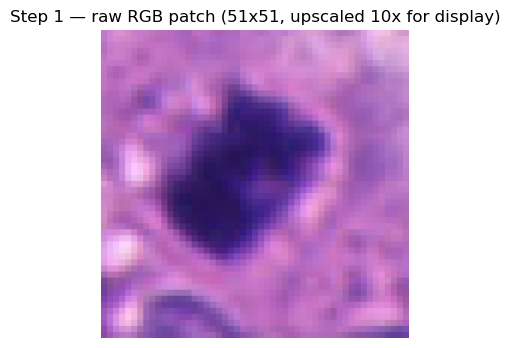

In [3]:
def upscale(arr_or_img, factor=10):
    im = arr_or_img if isinstance(arr_or_img, Image.Image) else Image.fromarray(arr_or_img)
    return im.resize((im.width * factor, im.height * factor), Image.NEAREST)

SCALE = 10  # for display only -- the patch itself stays BASE_SIZE x BASE_SIZE

rgb_patch = tm.read_padded_patch(rgb, cx, cy, tm.BASE_SIZE)
print("rgb_patch shape:", rgb_patch.shape, rgb_patch.dtype)

plt.figure(figsize=(4, 4))
plt.imshow(upscale(rgb_patch, SCALE))
plt.title(f"Step 1 — raw RGB patch ({tm.BASE_SIZE}x{tm.BASE_SIZE}, upscaled {SCALE}x for display)")
plt.axis("off")
plt.show()

## Step 2 — grayscale, then invert (`channels.to_gray_inverted`)

Seed selection's structural channel is **always** `gray_inverted`, independent of
whatever channel the later template search uses (`experiment.py`) — chosen because
Otsu/connected-components just needs a stable "object vs. background" contrast map,
not a stain-selective one.

H&E stains chromatin *dark* on a lighter pink/purple background. Otsu and connected
components below both operate on a "more object -> higher value" convention, so the
grayscale value is inverted (`255 - gray`) — the dense, dark nucleus becomes the
*bright* region the rest of the pipeline looks for.

inverted patch matches channels.to_gray_inverted(rgb) exactly


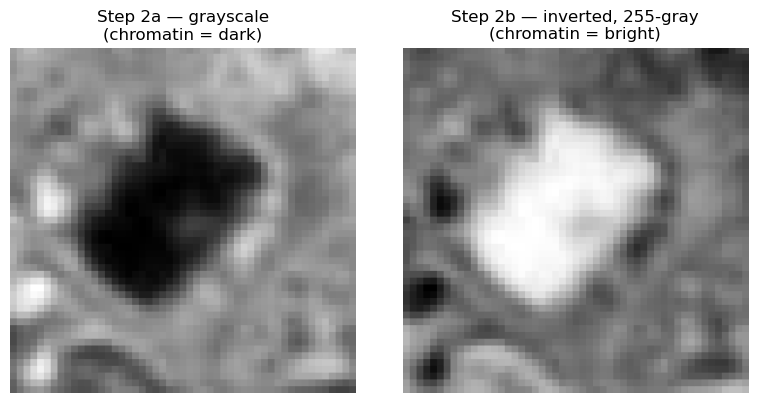

In [4]:
gray_patch = cv2.cvtColor(rgb_patch, cv2.COLOR_RGB2GRAY)
inverted_patch = 255.0 - gray_patch.astype(np.float32)

# Sanity check: this is exactly what channels.to_gray_inverted(rgb) gives when cropped
# the same way -- confirms the manual steps below track the real channel function.
structural = channels.to_gray_inverted(rgb)
patch = tm.read_padded_patch(structural, cx, cy, tm.BASE_SIZE)
assert np.allclose(inverted_patch, patch)
print("inverted patch matches channels.to_gray_inverted(rgb) exactly")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(upscale(gray_patch, SCALE), cmap="gray")
axes[0].set_title("Step 2a — grayscale\n(chromatin = dark)")
axes[0].axis("off")
axes[1].imshow(upscale(inverted_patch.astype(np.uint8), SCALE), cmap="gray")
axes[1].set_title("Step 2b — inverted, 255-gray\n(chromatin = bright)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Step 3 — normalize to uint8

`tighten_box_otsu` rescales the patch's own min-max range to the full `0-255` `uint8`
range (`cv2.normalize(..., cv2.NORM_MINMAX)`) before thresholding. This is a per-patch
rescale, distinct from `channels.to_hematoxylin`'s ROI-wide percentile rescale — it
just gives Otsu (which expects `uint8`) full use of the range within *this* small crop.

before: [27.0, 222.0]  ->  after: [0, 255]


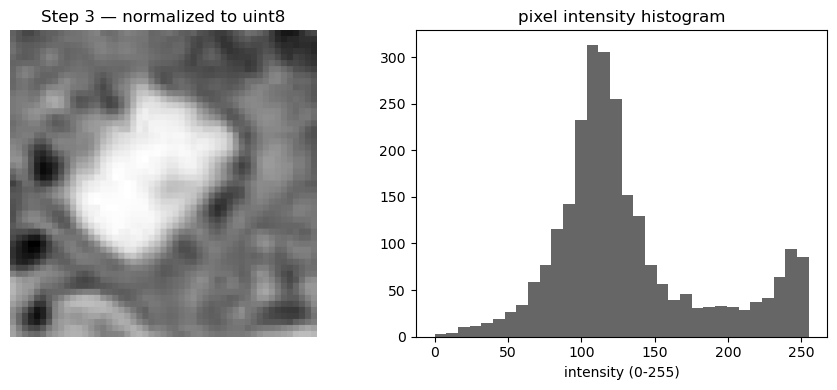

In [5]:
u8 = cv2.normalize(patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
print(f"before: [{patch.min():.1f}, {patch.max():.1f}]  ->  after: [{u8.min()}, {u8.max()}]")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(upscale(u8, SCALE), cmap="gray")
axes[0].set_title("Step 3 — normalized to uint8")
axes[0].axis("off")
axes[1].hist(u8.ravel(), bins=32, color="0.4")
axes[1].set_title("pixel intensity histogram")
axes[1].set_xlabel("intensity (0-255)")
plt.tight_layout()
plt.show()

## Step 4 — Otsu threshold

`cv2.threshold(..., cv2.THRESH_BINARY + cv2.THRESH_OTSU)` picks the intensity value
that best splits the patch's own histogram into two classes (foreground/background) —
no hand-tuned relative threshold, unlike the 1D cross-profile method this replaced
(`Research Logs/2026-08-25-bbox-tuning-domain-mismatch.md`, experiments 1-3).

Otsu threshold: 163/255  |  foreground pixels: 545/2601 (21%)


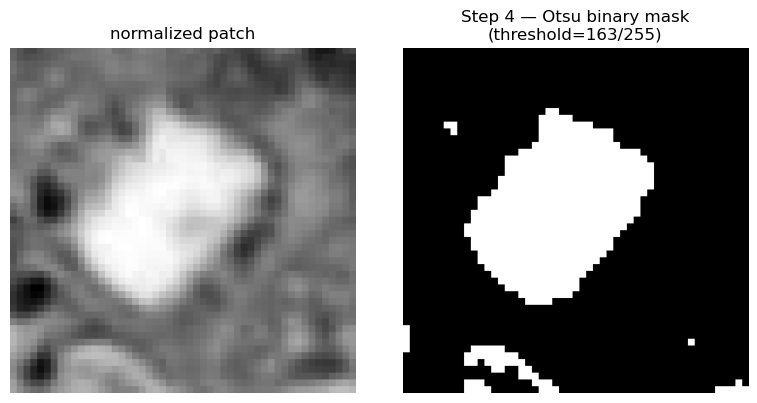

In [6]:
otsu_thresh, binary = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
n_fg = int((binary > 0).sum())
print(f"Otsu threshold: {otsu_thresh:.0f}/255  |  foreground pixels: {n_fg}/{binary.size} ({100*n_fg/binary.size:.0f}%)")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(upscale(u8, SCALE), cmap="gray")
axes[0].axhline(0, color="none")
axes[0].set_title("normalized patch")
axes[0].axis("off")
axes[1].imshow(upscale(binary, SCALE), cmap="gray")
axes[1].set_title(f"Step 4 — Otsu binary mask\n(threshold={otsu_thresh:.0f}/255)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Step 5 — connected-component labeling

`skimage.measure.label(binary, connectivity=2)` (8-connectivity) separates the binary
mask into individually numbered blobs. A different, non-touching dark nucleus
elsewhere in the crop becomes its own label and is automatically excluded from
whatever gets picked next — no explicit "ignore other nuclei" logic needed.

Step 5 — 7 connected component(s) found in this patch


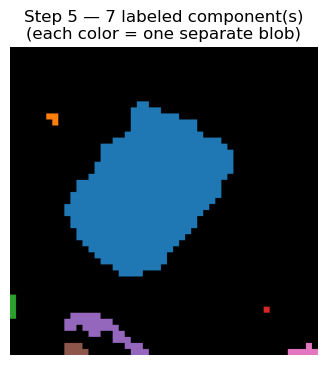

In [7]:
labels_arr = label(binary, connectivity=2)
n_components = int(labels_arr.max())
print(f"Step 5 — {n_components} connected component(s) found in this patch")

cmap = plt.get_cmap("tab10")
label_rgb = np.zeros((*labels_arr.shape, 3), dtype=np.uint8)
for lbl in range(1, n_components + 1):
    color = (np.array(cmap((lbl - 1) % 10)[:3]) * 255).astype(np.uint8)
    label_rgb[labels_arr == lbl] = color

plt.figure(figsize=(4, 4))
plt.imshow(upscale(label_rgb, SCALE))
plt.title(f"Step 5 — {n_components} labeled component(s)\n(each color = one separate blob)")
plt.axis("off")
plt.show()

## Step 6 — select the component under the click, then sanity-check it

The click is always the patch's centre pixel (the annotation box is built as
`point ± 25`, and the window here is that same box). Whichever labeled component sits
under that pixel is the candidate; if the centre pixel is background (`label == 0`),
`tighten_box_otsu` returns `None` rather than falling back to "the biggest blob in the
crop" — see the rejected-example section below for why.

An accepted component still has to pass three sanity checks
(`seed_selection.tighten_box_otsu`, `Research Logs/design_choices.md` section 2):

- `min_area=50` — rejects a degenerate sliver.
- `max_area_frac=0.85` of the window's pixel count — rejects a component that has
  grown implausibly large (bridged into a neighbour).
- `min_solidity=0.5` (filled area / convex-hull area) — rejects a concave,
  dumbbell-shaped merge of two touching nuclei; a real elongated mitotic figure stays
  convex enough to pass.

centre pixel (25, 25) has label 1
component area=490px  solidity=0.93  bbox=(9, 9, 38, 37)
  [PASS] min_area (>= 50)
  [PASS] max_area_frac (<= 0.85 * window)
  [PASS] min_solidity (>= 0.5)


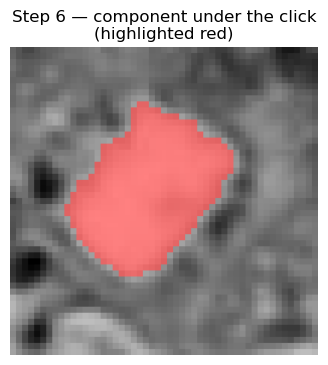

In [8]:
cy_p, cx_p = patch.shape[0] // 2, patch.shape[1] // 2
center_label = labels_arr[cy_p, cx_p]
print(f"centre pixel ({cx_p}, {cy_p}) has label {center_label}")

region = next(p for p in regionprops(labels_arr) if p.label == center_label)
min_row, min_col, max_row, max_col = region.bbox

checks = {
    "min_area (>= 50)": region.area >= 50,
    "max_area_frac (<= 0.85 * window)": region.area <= 0.85 * patch.size,
    "min_solidity (>= 0.5)": region.solidity >= 0.5,
}
print(f"component area={region.area:.0f}px  solidity={region.solidity:.2f}  bbox={region.bbox}")
for name, passed in checks.items():
    print(f"  [{'PASS' if passed else 'FAIL'}] {name}")

mask = labels_arr == center_label
overlay = np.stack([u8, u8, u8], axis=-1).copy()
overlay[mask] = (overlay[mask] * 0.35 + np.array([255, 60, 60]) * 0.65).astype(np.uint8)
plt.figure(figsize=(4, 4))
plt.imshow(upscale(overlay, SCALE))
plt.title("Step 6 — component under the click\n(highlighted red)")
plt.axis("off")
plt.show()

## Step 7 — final tightened box, cross-checked against production code

The selected component's bounding box (`skimage`'s `region.bbox`, already
`(min_row, min_col, max_row, max_col)`, half-open) *is* the tightened box, in
patch-local coordinates. Below: overlay the original 50x50 annotation box (yellow)
against the tightened box (red), first on the small patch, then mapped back onto the
full-resolution ROI — and confirm this manual, step-by-step result is bit-for-bit what
`seed_selection.tighten_box_otsu` returns when called directly on the same patch.

manual result:    (9, 38, 9, 37)
tighten_box_otsu: (9, 38, 9, 37)
-> identical: this walkthrough matches the production function exactly.

original annotation box: 50x50 (synthetic, point +/- 25)
tightened box:           28x29, offset (9,9) within the patch
(both drawn against the 51x51 Otsu window the tightening itself used)

tightened_base_size() -> 29px (odd, longer side of the tightened box) -- this is what feeds FSConfig(base_size=...)


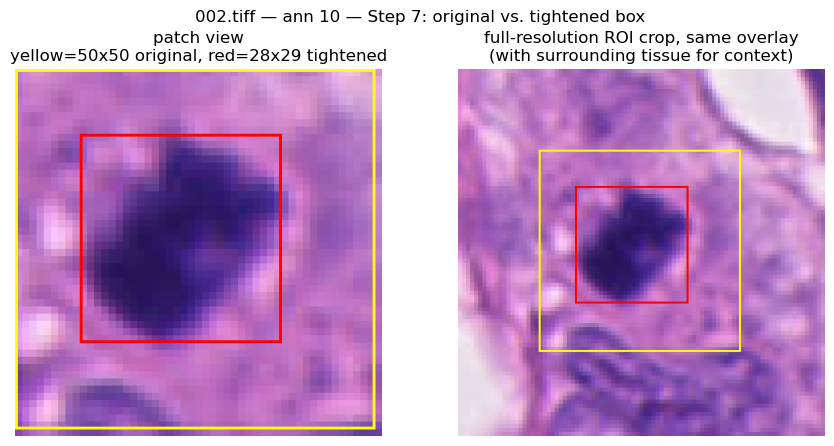

In [9]:
manual_box = (int(min_row), int(max_row), int(min_col), int(max_col))  # (y0, y1, x0, x1)
prod_box = ss.tighten_box_otsu(patch)
print("manual result:   ", manual_box)
print("tighten_box_otsu:", prod_box)
assert manual_box == prod_box
print("-> identical: this walkthrough matches the production function exactly.\n")

y0, y1, x0, x1 = manual_box
w_new, h_new = x1 - x0, y1 - y0

# The *true* synthetic annotation box is 50x50 (point +/- 25) -- distinct from the
# 51x51 Otsu window (BASE_SIZE, made odd so the click is exactly the centre pixel).
# Map it into patch-local coordinates from the patch's own origin in full-ROI space.
patch_half = tm.BASE_SIZE // 2
patch_origin_x, patch_origin_y = round(cx) - patch_half, round(cy) - patch_half
ann_w, ann_h = float(row["w"]), float(row["h"])
ann_x0 = (cx - ann_w / 2) - patch_origin_x
ann_y0 = (cy - ann_h / 2) - patch_origin_y
ann_x1, ann_y1 = ann_x0 + ann_w, ann_y0 + ann_h

print(f"original annotation box: {ann_w:.0f}x{ann_h:.0f} (synthetic, point +/- 25)")
print(f"tightened box:           {w_new}x{h_new}, offset ({x0},{y0}) within the patch")
print(f"(both drawn against the {tm.BASE_SIZE}x{tm.BASE_SIZE} Otsu window the tightening itself used)")

base_size = ss.tightened_base_size(structural, cx, cy)
print(f"\ntightened_base_size() -> {base_size}px "
      f"(odd, longer side of the tightened box) -- this is what feeds FSConfig(base_size=...)")

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))

im_patch = upscale(Image.fromarray(rgb_patch), SCALE)
d = ImageDraw.Draw(im_patch)
d.rectangle([ann_x0 * SCALE, ann_y0 * SCALE, ann_x1 * SCALE, ann_y1 * SCALE], outline="yellow", width=4)
d.rectangle([x0 * SCALE, y0 * SCALE, x1 * SCALE, y1 * SCALE], outline="red", width=4)
axes[0].imshow(im_patch)
axes[0].set_title(f"patch view\nyellow={ann_w:.0f}x{ann_h:.0f} original, red={w_new}x{h_new} tightened")
axes[0].axis("off")

margin = 20
full_x0, full_y0 = int(cx - tm.BASE_SIZE // 2 - margin), int(cy - tm.BASE_SIZE // 2 - margin)
full_size = tm.BASE_SIZE + 2 * margin
crop_full = rgb[full_y0:full_y0 + full_size, full_x0:full_x0 + full_size]
im_full = upscale(Image.fromarray(crop_full), 6)
d2 = ImageDraw.Draw(im_full)
offset_x, offset_y = patch_origin_x - full_x0, patch_origin_y - full_y0
d2.rectangle([(offset_x + ann_x0) * 6, (offset_y + ann_y0) * 6, (offset_x + ann_x1) * 6, (offset_y + ann_y1) * 6], outline="yellow", width=3)
d2.rectangle([(offset_x + x0) * 6, (offset_y + y0) * 6, (offset_x + x1) * 6, (offset_y + y1) * 6], outline="red", width=3)
axes[1].imshow(im_full)
axes[1].set_title("full-resolution ROI crop, same overlay\n(with surrounding tissue for context)")
axes[1].axis("off")

fig.suptitle(f"{FNAME} — ann {ANN_ID} — Step 7: original vs. tightened box", fontsize=12)
plt.tight_layout()
plt.show()

## A rejected example — the click sits outside its own object's mask

`ann_id=20` in the same image fails Step 6's centre-pixel check: the annotated point
sits right on the *edge* of the nucleus rather than solidly inside it, so after Otsu
thresholding the centre pixel itself is background. The old reference implementation
(`bbox tuning code reference/`) would silently fall back to "the largest component in
the crop" here — but that is a weak heuristic (in a crowded crop it can grab an
unrelated, larger structure entirely). The production code instead **excludes** the
annotation from the candidate pool rather than guessing
(`Research Logs/design_choices.md` section 2; `Research Logs/2026-08-25-bbox-tuning-domain-mismatch.md`,
experiment 5). `foreground_filter` applies this exclusion automatically when narrowing
a seed pool.

ann 20: centre-pixel label = 0 (0 = background)
tighten_box_otsu(patch) -> None


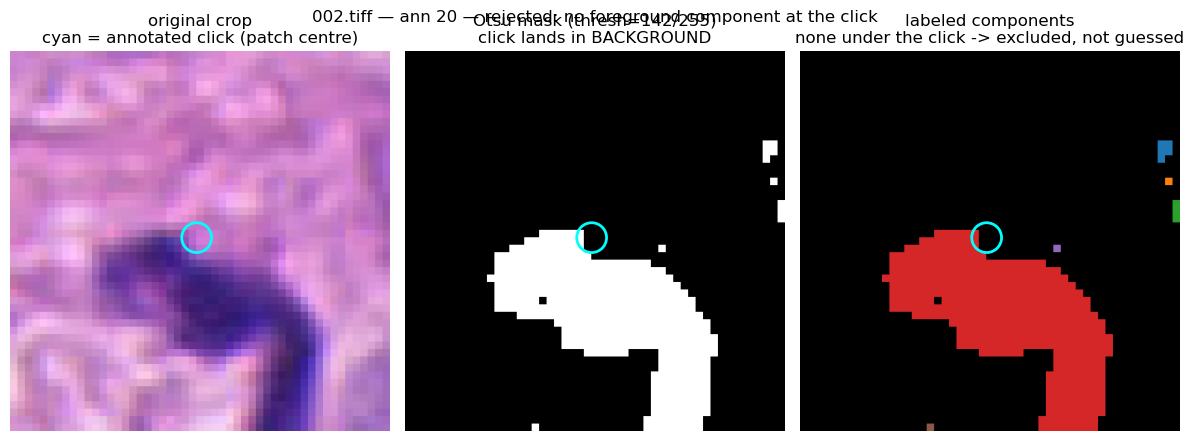

In [10]:
ANN_ID_REJECTED = 20
row_r = mit[mit["ann_id"] == ANN_ID_REJECTED].iloc[0]
cx_r, cy_r = float(row_r["cx"]), float(row_r["cy"])

rgb_patch_r = tm.read_padded_patch(rgb, cx_r, cy_r, tm.BASE_SIZE)
patch_r = tm.read_padded_patch(structural, cx_r, cy_r, tm.BASE_SIZE)
u8_r = cv2.normalize(patch_r.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
otsu_r, binary_r = cv2.threshold(u8_r, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
labels_r = label(binary_r, connectivity=2)
cy_pr, cx_pr = patch_r.shape[0] // 2, patch_r.shape[1] // 2
center_label_r = labels_r[cy_pr, cx_pr]

print(f"ann {ANN_ID_REJECTED}: centre-pixel label = {center_label_r} (0 = background)")
print("tighten_box_otsu(patch) ->", ss.tighten_box_otsu(patch_r))

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))
axes[0].imshow(upscale(rgb_patch_r, SCALE))
r_dot = 2
cxp, cyp = patch_r.shape[1] // 2, patch_r.shape[0] // 2
axes[0].add_patch(plt.Circle((cxp * SCALE, cyp * SCALE), r_dot * SCALE, fill=False, color="cyan", linewidth=2))
axes[0].set_title("original crop\ncyan = annotated click (patch centre)")
axes[0].axis("off")

axes[1].imshow(upscale(binary_r, SCALE), cmap="gray")
axes[1].add_patch(plt.Circle((cxp * SCALE, cyp * SCALE), r_dot * SCALE, fill=False, color="cyan", linewidth=2))
axes[1].set_title(f"Otsu mask (thresh={otsu_r:.0f}/255)\nclick lands in BACKGROUND")
axes[1].axis("off")

label_rgb_r = np.zeros((*labels_r.shape, 3), dtype=np.uint8)
cmap = plt.get_cmap("tab10")
for lbl in range(1, int(labels_r.max()) + 1):
    color = (np.array(cmap((lbl - 1) % 10)[:3]) * 255).astype(np.uint8)
    label_rgb_r[labels_r == lbl] = color
axes[2].imshow(upscale(label_rgb_r, SCALE))
axes[2].add_patch(plt.Circle((cxp * SCALE, cyp * SCALE), r_dot * SCALE, fill=False, color="cyan", linewidth=2))
axes[2].set_title("labeled components\nnone under the click -> excluded, not guessed")
axes[2].axis("off")

fig.suptitle(f"{FNAME} — ann {ANN_ID_REJECTED} — rejected: no foreground component at the click", fontsize=12)
plt.tight_layout()
plt.show()

## A simpler alternative: always take the largest connected component

Every method above accepts a component only when the click's own pixel lands inside
it -- reject otherwise (`Research Logs/design_choices.md`, section 2). That choice was
deliberate: an earlier exploration tried falling back to "the largest component in the
crop" only when the centre check failed, and flagged it as a weak, crowd-sensitive
heuristic rather than adopting it
(`Research Logs/2026-08-25-bbox-tuning-domain-mismatch.md`, Experiment 5).

This section builds a different, simpler policy instead of that fallback: **always take
the largest connected component in the crop, full stop.** No centre-pixel check at all
-- the click no longer has to land anywhere near the tightened box for one to be
produced. This trades away "the click told us this IS the target object" for a policy
that (almost) never refuses an annotation and needs no assumption about click precision.

Same primitives as every step above (grayscale-invert -> normalize -> Otsu -> connected
components), with the centre-pixel logic simply removed: whichever labelled blob has the
most pixels is the answer.

In [11]:
def tighten_box_largest_cc(patch):
    """Otsu-threshold ``patch`` and return the bounding box of its LARGEST connected
    component -- no requirement that the click's own pixel be inside it, unlike every
    method above. Returns ``(y0, y1, x0, x1)`` (half-open, patch-local), or ``None``
    only when the whole crop is background (no foreground pixels anywhere)."""
    u8 = cv2.normalize(patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, binary = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    labels_arr = label(binary, connectivity=2)
    if labels_arr.max() == 0:
        return None  # no foreground anywhere in the crop
    largest = max(regionprops(labels_arr), key=lambda p: p.area)
    min_row, min_col, max_row, max_col = largest.bbox
    return (int(min_row), int(max_row), int(min_col), int(max_col))


# Same annotation as the walkthrough above (ann 10) -- here the click already sat
# inside the object, so the largest component in the crop should usually agree with
# the centre-gated production result.
largest_cc_box_10 = tighten_box_largest_cc(patch)
print(f"ann {ANN_ID}: centre-gated production result: {prod_box}")
print(f"ann {ANN_ID}: largest-CC result:              {largest_cc_box_10}")
print("same box:", largest_cc_box_10 == prod_box)

ann 10: centre-gated production result: (9, 38, 9, 37)
ann 10: largest-CC result:              (9, 38, 9, 37)
same box: True


ann 20: centre-gated production result: None (excluded)
ann 20: largest-CC result:              (24, 51, 11, 42)


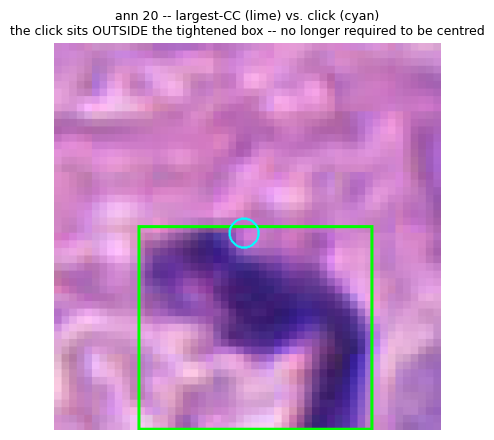

In [12]:
# The interesting case: ann 20, where the centre-gated method above returned None
# (the click sits in background, just outside its own object's mask). largest-CC
# does not look at the click at all, so it still produces a box.
largest_cc_box_20 = tighten_box_largest_cc(patch_r)
print(f"ann {ANN_ID_REJECTED}: centre-gated production result: None (excluded)")
print(f"ann {ANN_ID_REJECTED}: largest-CC result:              {largest_cc_box_20}")

fig, ax = plt.subplots(figsize=(4.5, 4.5))
im = upscale(Image.fromarray(rgb_patch_r), SCALE)
d = ImageDraw.Draw(im)
if largest_cc_box_20 is not None:
    ly0, ly1, lx0, lx1 = largest_cc_box_20
    d.rectangle([lx0 * SCALE, ly0 * SCALE, lx1 * SCALE, ly1 * SCALE], outline="lime", width=4)
r_dot = 2
d.ellipse([(cxp - r_dot) * SCALE, (cyp - r_dot) * SCALE, (cxp + r_dot) * SCALE, (cyp + r_dot) * SCALE],
          outline="cyan", width=3)
ax.imshow(im)
ax.set_title(
    f"ann {ANN_ID_REJECTED} -- largest-CC (lime) vs. click (cyan)\n"
    "the click sits OUTSIDE the tightened box -- no longer required to be centred",
    fontsize=9,
)
ax.axis("off")
plt.tight_layout()
plt.savefig("debug_pics/bbox_tuning_largest_cc_ann20.png", dpi=130)
plt.show()

## Every domain: one image, examples of tightening in action

The rest of this notebook runs the exact same `tighten_box_otsu` call — no manual
step-by-step this time — across one downloaded sample image from each of the seven
MIDOG++ tumor-type domains, on however many mitotic annotations that image has (capped
at 9). Yellow = original synthetic 50x50 box, red = tightened box; annotations the
method rejects are labeled "excluded" rather than given a guessed box.

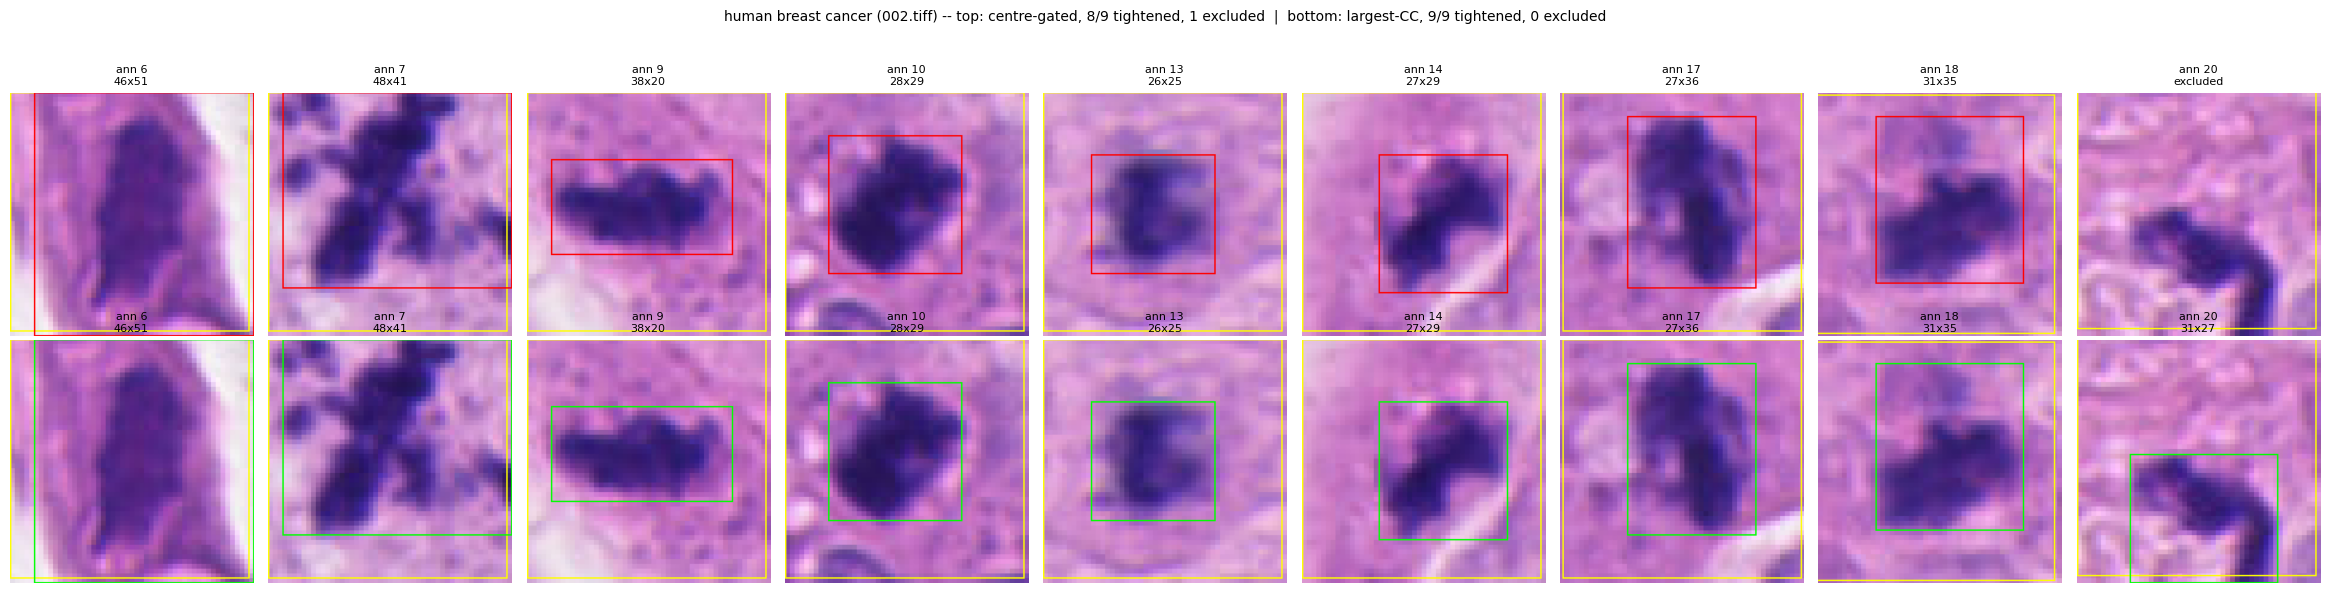

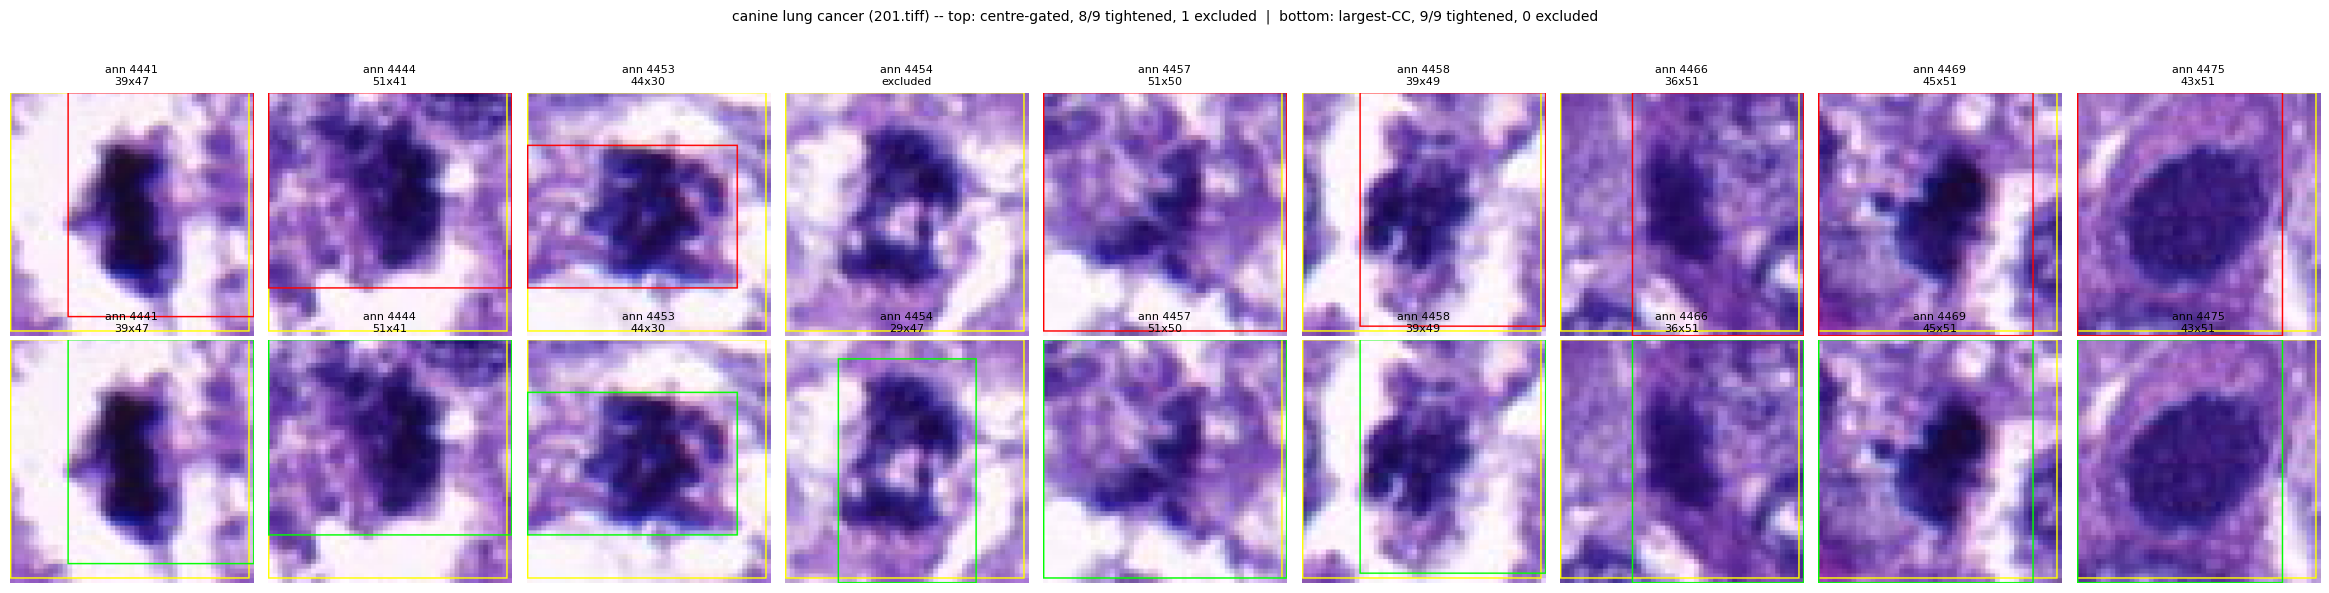

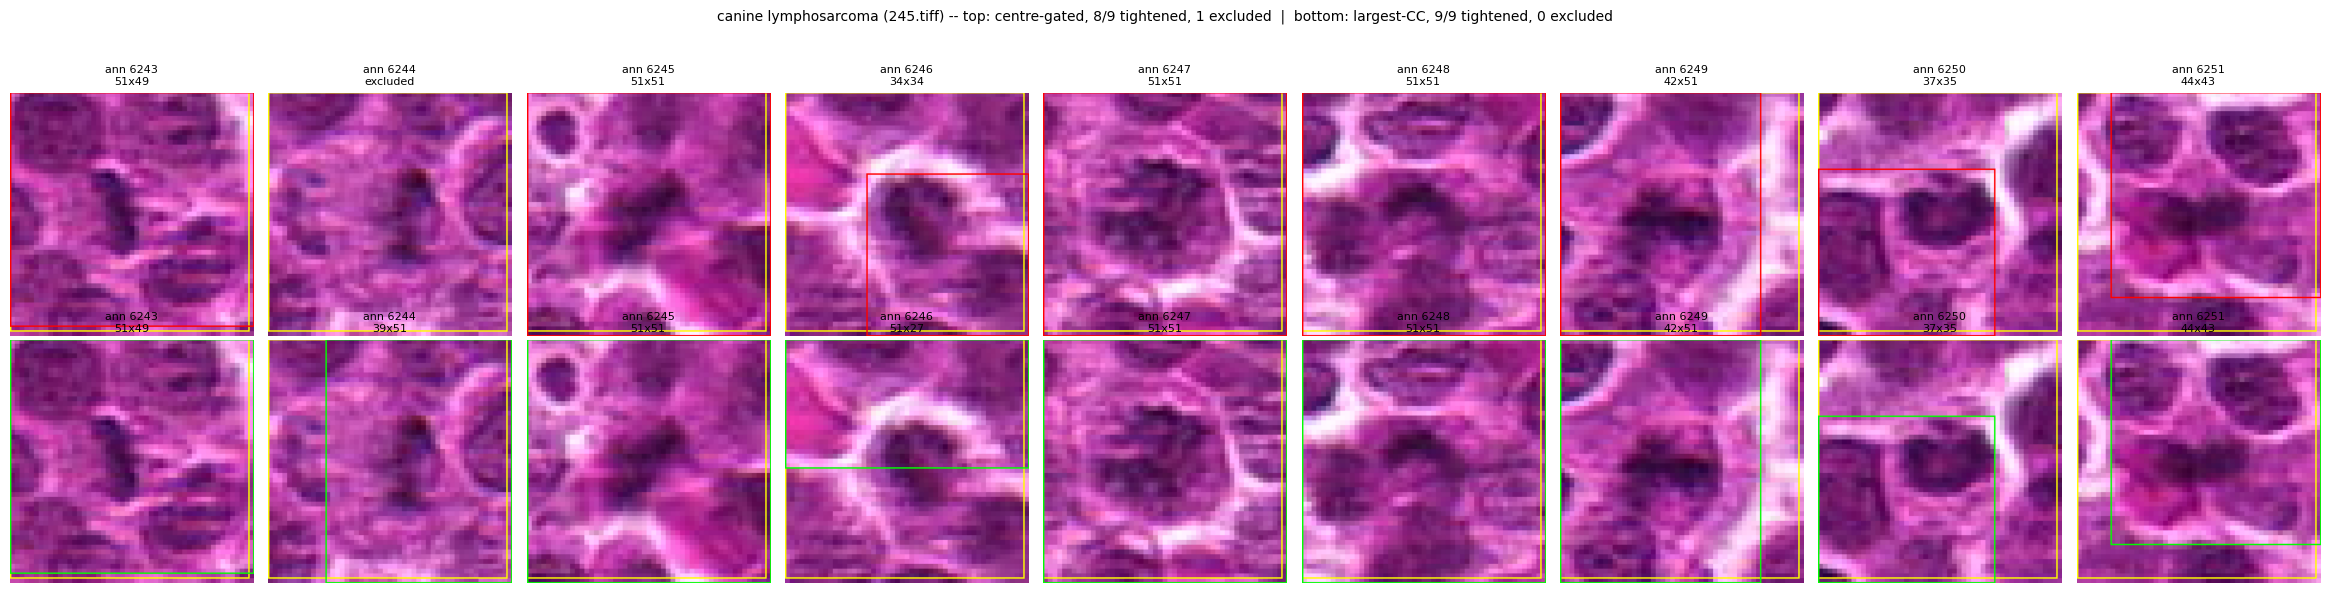

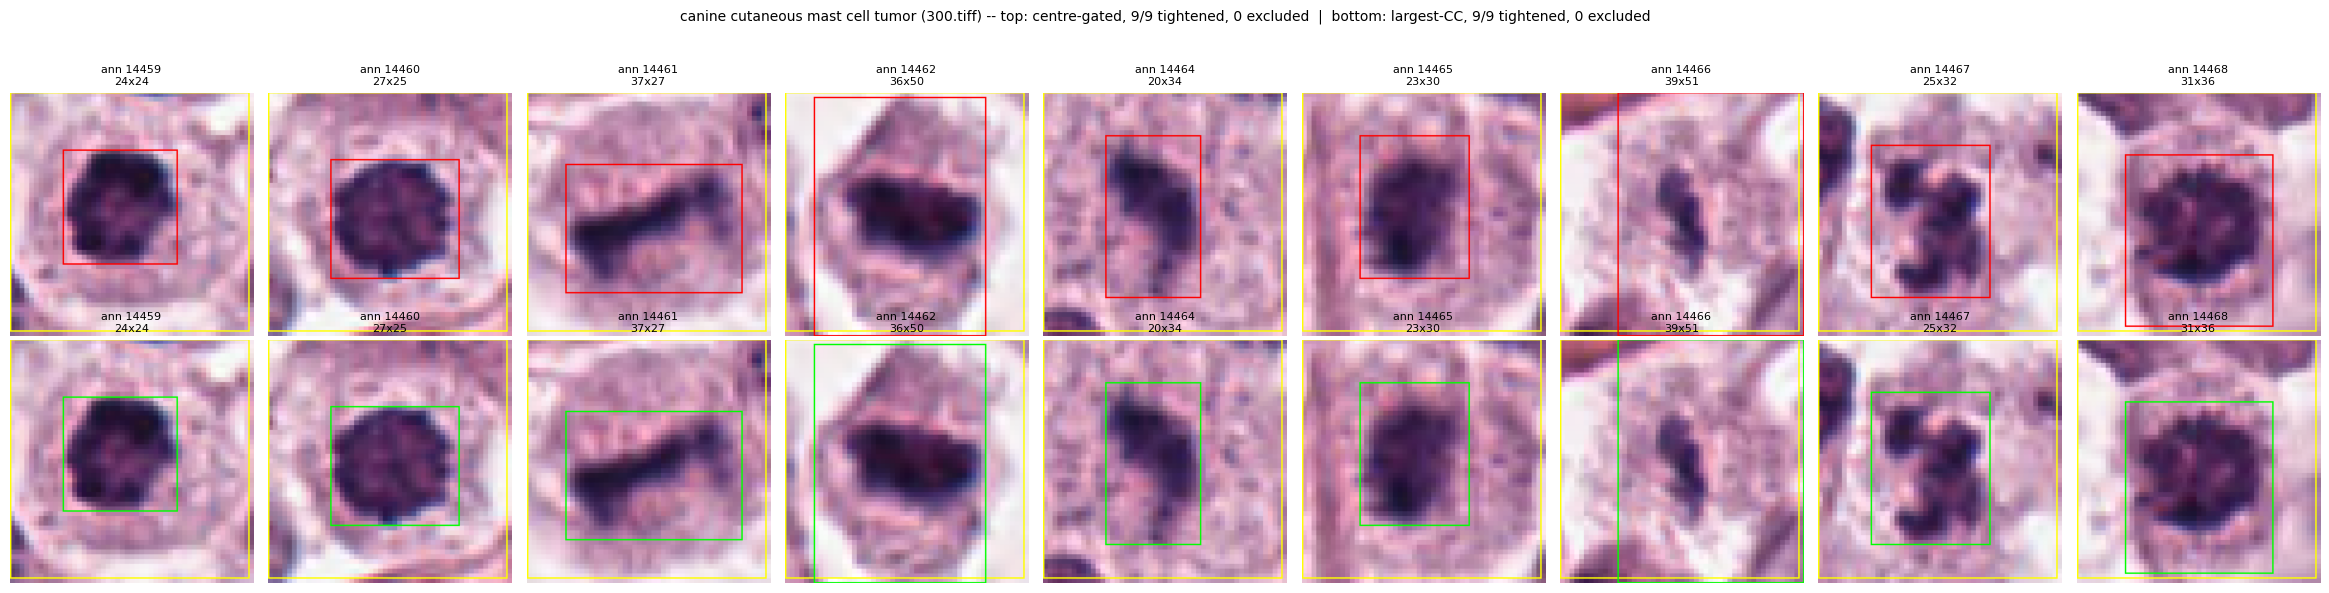

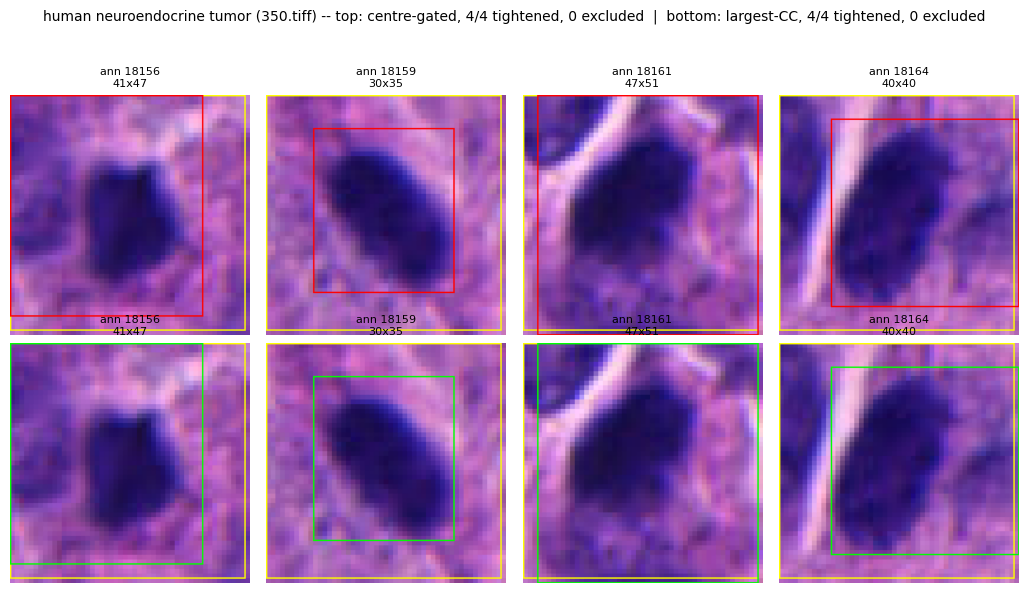

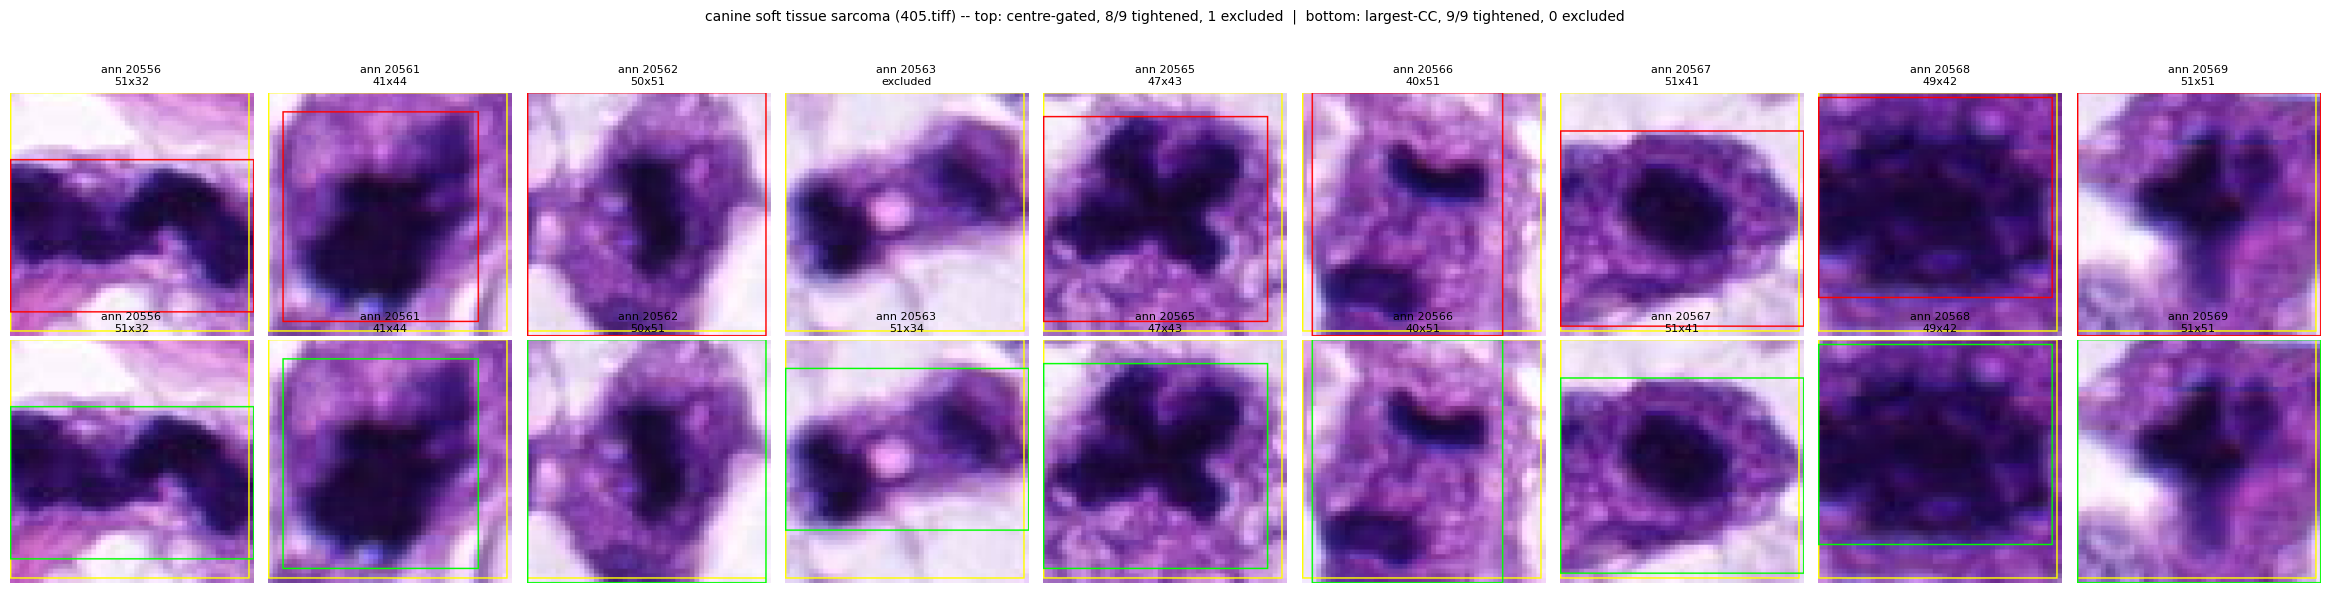

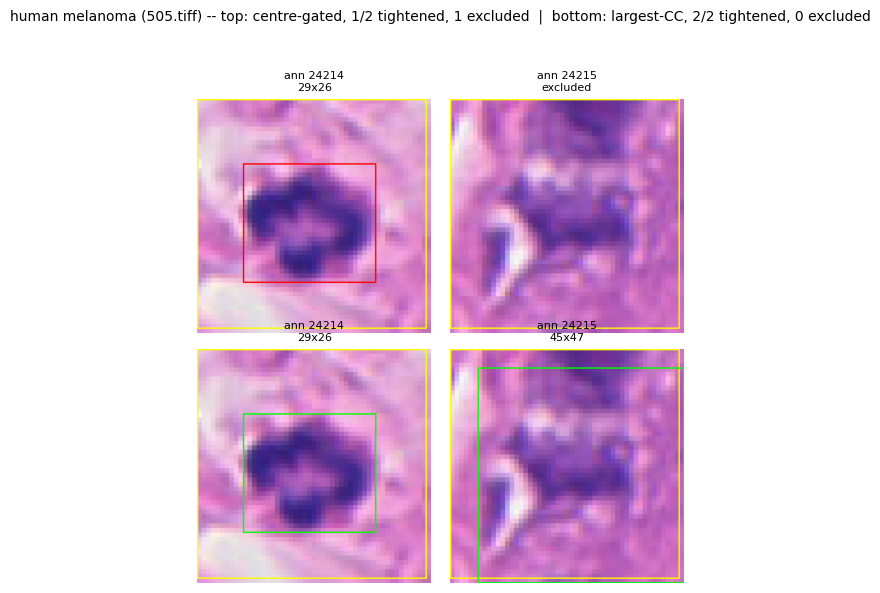

In [13]:
DOMAIN_FILES = {
    "human breast cancer": "002.tiff",
    "canine lung cancer": "201.tiff",
    "canine lymphosarcoma": "245.tiff",
    "canine cutaneous mast cell tumor": "300.tiff",
    "human neuroendocrine tumor": "350.tiff",
    "canine soft tissue sarcoma": "405.tiff",
    "human melanoma": "505.tiff",
}
N_PER_DOMAIN = 9

Path("debug_pics").mkdir(exist_ok=True)
domain_summary = []

for domain, fname in DOMAIN_FILES.items():
    d_rgb = dataset.load_roi(IMAGES_DIR / fname)
    d_structural = channels.to_gray_inverted(d_rgb)
    d_mit = dataset.image_annotations(anns, fname, category_id=1).head(N_PER_DOMAIN)

    items = []
    for _, r in d_mit.iterrows():
        d_cx, d_cy = float(r["cx"]), float(r["cy"])
        d_rgb_patch = tm.read_padded_patch(d_rgb, d_cx, d_cy, tm.BASE_SIZE)
        d_patch = tm.read_padded_patch(d_structural, d_cx, d_cy, tm.BASE_SIZE)
        box = ss.tighten_box_otsu(d_patch) if d_patch is not None else None
        lcc_box = tighten_box_largest_cc(d_patch) if d_patch is not None else None

        # true 50x50 synthetic box, mapped into this patch's local coordinates
        d_half = tm.BASE_SIZE // 2
        d_ox, d_oy = round(d_cx) - d_half, round(d_cy) - d_half
        d_ann_w, d_ann_h = float(r["w"]), float(r["h"])
        d_ann_box = (d_cx - d_ann_w / 2 - d_ox, d_cy - d_ann_h / 2 - d_oy,
                     d_cx + d_ann_w / 2 - d_ox, d_cy + d_ann_h / 2 - d_oy)
        items.append((r["ann_id"], d_rgb_patch, box, lcc_box, d_ann_box))

    n_ok = sum(1 for _, _, b, _, _ in items if b is not None)
    n_lcc_ok = sum(1 for _, _, _, b, _ in items if b is not None)
    domain_summary.append((domain, fname, len(items), n_ok, len(items) - n_ok, n_lcc_ok, len(items) - n_lcc_ok))

    n = len(items)
    fig, axes = plt.subplots(2, n, figsize=(2.6 * n, 6))
    if n == 1:
        axes = axes.reshape(2, 1)
    for col, (ann_id, rgb_patch_i, box, lcc_box, ann_box) in enumerate(items):
        ax0, ay0, ax1, ay1 = ann_box

        im_top = upscale(Image.fromarray(rgb_patch_i), SCALE)
        d_top = ImageDraw.Draw(im_top)
        d_top.rectangle([ax0 * SCALE, ay0 * SCALE, ax1 * SCALE, ay1 * SCALE], outline="yellow", width=3)
        title_top = f"ann {ann_id}"
        if box is not None:
            by0, by1, bx0, bx1 = box
            d_top.rectangle([bx0 * SCALE, by0 * SCALE, bx1 * SCALE, by1 * SCALE], outline="red", width=3)
            title_top += f"\n{bx1-bx0}x{by1-by0}"
        else:
            title_top += "\nexcluded"
        axes[0][col].imshow(im_top)
        axes[0][col].set_title(title_top, fontsize=8)
        axes[0][col].axis("off")

        im_bot = upscale(Image.fromarray(rgb_patch_i), SCALE)
        d_bot = ImageDraw.Draw(im_bot)
        d_bot.rectangle([ax0 * SCALE, ay0 * SCALE, ax1 * SCALE, ay1 * SCALE], outline="yellow", width=3)
        title_bot = f"ann {ann_id}"
        if lcc_box is not None:
            ly0, ly1, lx0, lx1 = lcc_box
            d_bot.rectangle([lx0 * SCALE, ly0 * SCALE, lx1 * SCALE, ly1 * SCALE], outline="lime", width=3)
            title_bot += f"\n{lx1-lx0}x{ly1-ly0}"
        else:
            title_bot += "\nexcluded"
        axes[1][col].imshow(im_bot)
        axes[1][col].set_title(title_bot, fontsize=8)
        axes[1][col].axis("off")

    axes[0][0].set_ylabel("centre-gated\n(production)", fontsize=9)
    axes[1][0].set_ylabel("largest-CC\n(this section)", fontsize=9)

    safe = domain.replace(" ", "_")
    fig.suptitle(
        f"{domain} ({fname}) -- top: centre-gated, {n_ok}/{n} tightened, {n - n_ok} excluded  |  "
        f"bottom: largest-CC, {n_lcc_ok}/{n} tightened, {n - n_lcc_ok} excluded",
        fontsize=10,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    fig.savefig(f"debug_pics/bbox_tuning_demo_{safe}.png", dpi=130)
    plt.show()

## Summary across domains

                          domain     file  n  tightened  excluded  lcc_tightened  lcc_excluded  excluded_pct  lcc_excluded_pct
             human breast cancer 002.tiff  9          8         1              9             0          11.0               0.0
              canine lung cancer 201.tiff  9          8         1              9             0          11.0               0.0
            canine lymphosarcoma 245.tiff  9          8         1              9             0          11.0               0.0
canine cutaneous mast cell tumor 300.tiff  9          9         0              9             0           0.0               0.0
      human neuroendocrine tumor 350.tiff  4          4         0              4             0           0.0               0.0
      canine soft tissue sarcoma 405.tiff  9          8         1              9             0          11.0               0.0
                  human melanoma 505.tiff  2          1         1              2             0          50.0   

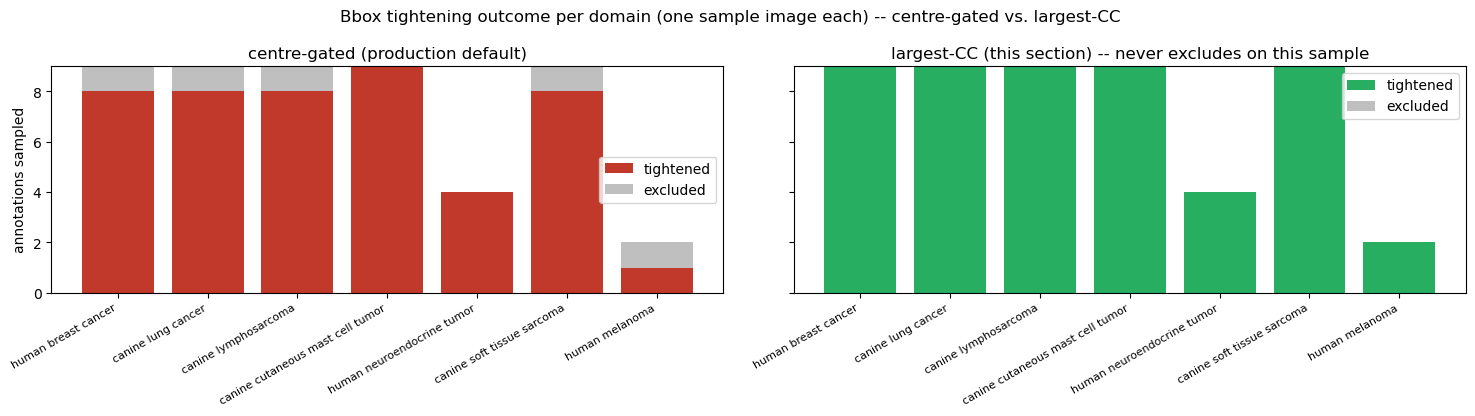

In [14]:
import pandas as pd

summary_df = pd.DataFrame(
    domain_summary,
    columns=["domain", "file", "n", "tightened", "excluded", "lcc_tightened", "lcc_excluded"],
)
summary_df["excluded_pct"] = (100 * summary_df["excluded"] / summary_df["n"]).round(0)
summary_df["lcc_excluded_pct"] = (100 * summary_df["lcc_excluded"] / summary_df["n"]).round(0)
print(summary_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.2), sharey=True)
x = np.arange(len(summary_df))

axes[0].bar(x, summary_df["tightened"], color="#c0392b", label="tightened")
axes[0].bar(x, summary_df["excluded"], bottom=summary_df["tightened"], color="0.75", label="excluded")
axes[0].set_xticks(x)
axes[0].set_xticklabels(summary_df["domain"], rotation=30, ha="right", fontsize=8)
axes[0].set_ylabel("annotations sampled")
axes[0].set_title("centre-gated (production default)")
axes[0].legend()

axes[1].bar(x, summary_df["lcc_tightened"], color="#27ae60", label="tightened")
axes[1].bar(x, summary_df["lcc_excluded"], bottom=summary_df["lcc_tightened"], color="0.75", label="excluded")
axes[1].set_xticks(x)
axes[1].set_xticklabels(summary_df["domain"], rotation=30, ha="right", fontsize=8)
axes[1].set_title("largest-CC (this section) -- never excludes on this sample")
axes[1].legend()

fig.suptitle("Bbox tightening outcome per domain (one sample image each) -- centre-gated vs. largest-CC", fontsize=12)
plt.tight_layout()
plt.show()

## Where this goes next

- `midog_utils.seed_selection.pick_seed` runs `foreground_filter` (the centre-gated
  accept/exclude logic from the earlier sections) as one stage of choosing a template
  seed, alongside the pathologist-agreement filter -- see `BBOX_TUNING.md`.
- `tightened_base_size` turns an accepted box into the `base_size` used by
  `FSConfig` for the actual template-matching search (`midog_utils/experiment.py`).
- The `method="multiotsu"` and `center_tolerance` options tested-but-not-defaulted in
  the earlier sections are documented in `Research Logs/design_choices.md`, sections
  7/7a/7b.
- The largest-CC alternative built in this notebook is **not** part of
  `midog_utils.seed_selection` -- it lives only here, as a demonstration. A follow-up
  end-to-end experiment on a related question (does raising the Otsu threshold help or
  hurt actual detection quality, not just seed-selection geometry) found that a
  geometrically "cleaner" box is not automatically a better template: an over-tight or
  otherwise miscalibrated box can inflate the downstream candidate list and *hurt*
  recall (`Research Logs/2026-09-03-bbox-headroom-end-to-end.md`). The same caution
  applies here -- a policy that never refuses an annotation is convenient, but whether
  its boxes make *better* templates than the centre-gated default is a separate,
  unmeasured question this notebook does not answer.